<a href="https://colab.research.google.com/github/Rakmik/NM/blob/main/%D0%9B%D0%A0%E2%84%967_%D0%97%D0%B0%D0%B3%D0%B8%D0%BD%D0%B0%D0%B9%D0%BA%D0%BE_%D0%9F%D0%B0%D0%B2%D0%BB%D0%BE_%D0%A4%D0%86%D0%A2_2_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Загинайко Павло ФІТ 2-17

#Варіант 8

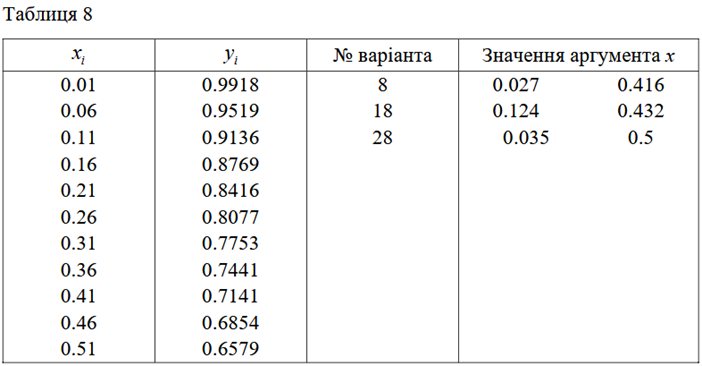

In [16]:
import numpy as np
from math import factorial
import matplotlib.pyplot as plt

In [17]:
x_data = np.array([0.01, 0.06, 0.11, 0.16, 0.21, 0.26, 0.31, 0.36, 0.41, 0.46, 0.51])
y_data = np.array([0.9918, 0.9519, 0.9136, 0.8769, 0.8416, 0.8077, 0.7753, 0.7441, 0.7141, 0.6854, 0.6579])

x1_target = 0.027
x2_target = 0.416

In [18]:
def get_finite_differences(y):
    n = len(y)
    delta = np.zeros((n, n))
    delta[:, 0] = y
    for j in range(1, n):
        for i in range(n - j):
            delta[i, j] = delta[i + 1, j - 1] - delta[i, j - 1]
    return delta


# Перша інтерполяційна формула Ньютона

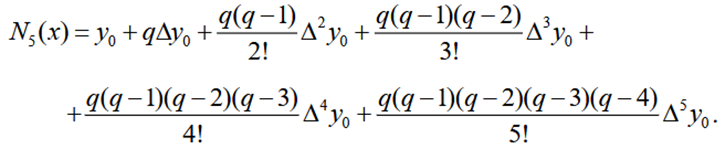

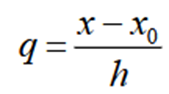

In [19]:
def newton_forward(x, y, x0):
    n = len(x)
    h = x[1] - x[0]
    delta = get_finite_differences(y)
    q = (x0 - x[0]) / h
    res = delta[0, 0]
    q_prod = 1
    for i in range(1, n):
        q_prod *= (q - i + 1)
        res += (q_prod * delta[0, i]) / factorial(i)
    return res

# Друга інтерполяційна формула Ньютона

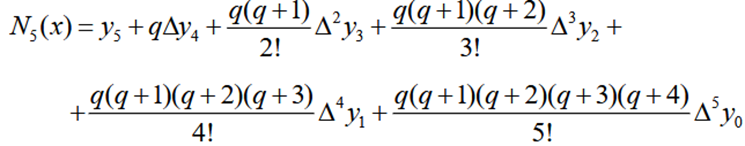

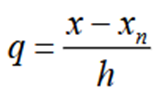

In [20]:
def newton_backward(x, y, x0):
    n = len(x)
    h = x[1] - x[0]
    delta = get_finite_differences(y)
    q = (x0 - x[-1]) / h
    res = delta[-1, 0]
    q_prod = 1
    for i in range(1, n):
        q_prod *= (q + i - 1)
        res += (q_prod * delta[n - i - 1, i]) / factorial(i)
    return res

# Обчислення

In [21]:
y1_res = newton_forward(x, y, x1)
y2_res = newton_backward(x, y, x2)

print(f"Результат (вперед) для x = {x1}: y = {y1_res:.6f}")
print(f"Результат (назад)  для x = {x2}: y = {y2_res:.6f}")

Результат (вперед) для x = 0.027: y = 0.977857
Результат (назад)  для x = 0.416: y = 0.710597


# Візуалізація

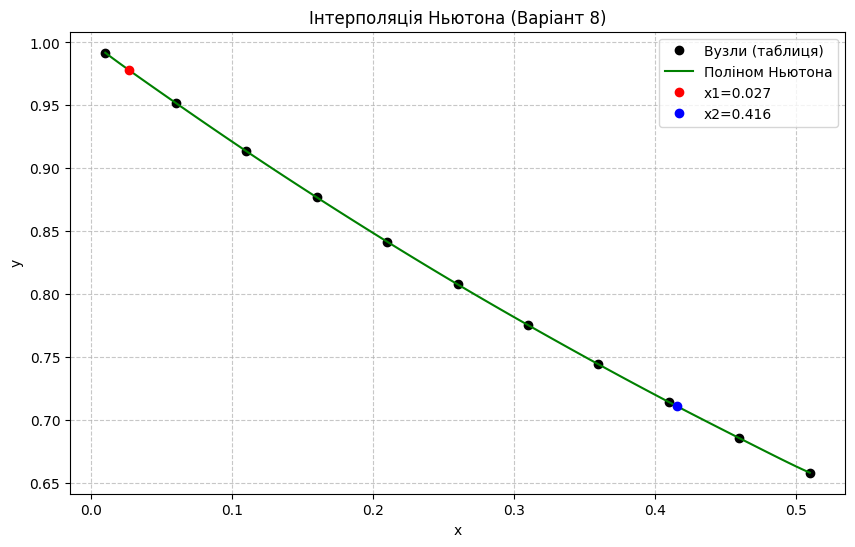

In [22]:
xx = np.linspace(x[0], x[-1], 100)
yy = [newton_forward(x, y, val) if val < 0.26 else newton_backward(x, y, val) for val in xx]

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'ko', label='Вузли (таблиця)')
plt.plot(xx, yy, 'g-', label='Поліном Ньютона')
plt.plot(x1, y1_res, 'ro', label=f'x1={x1}')
plt.plot(x2, y2_res, 'bo', label=f'x2={x2}')

plt.title("Інтерполяція Ньютона (Варіант 8)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()